# Experiment 3 — Augmentation Strategy Ablation
## Does augmentation choice matter for fundus-based OT classification under label scarcity?

| | |
|---|---|
| **Goal** | Identify which augmentation strategy maximises performance at low label counts |
| **Models** | ConvNeXt-Base · RETFound-DINOv2 (best two from E1) |
| **Label fractions** | 5% · 10% · 25% (scarcity regime where augmentation matters most) |
| **Strategies tested** | 6 augmentation pipelines (Baseline → Clinically-informed → MixUp → AugMix → CLAHE → No-Aug) |
| **Metric** | Macro AUC-ROC on internal test + external binary test |

### Augmentation strategies
| ID | Name | Description |
|---|---|---|
| A0 | **No-Aug** | Resize + ToTensor + Normalize only (lower bound) |
| A1 | **Baseline** | E1 strategy: flip + crop + ColorJitter + rotation (upper bound reference) |
| A2 | **Geometric-only** | Flip + crop + rotation — no colour changes |
| A3 | **Colour-only** | ColorJitter + brightness/contrast — no geometric |
| A4 | **CLAHE** | Contrast Limited Adaptive Histogram Equalisation + Baseline geo |
| A5 | **MixUp** | Baseline + MixUp (α=0.4) during training batches |
| A6 | **AugMix** | torchvision AugMix — stochastic mixture of augmentations |

### Why these strategies
- Geometric and colour augmentations provide the most stable improvements in fundus classification → test them separately (A2, A3) to understand which component drives the E1 results
- CLAHE is standard in ophthalmology preprocessing — enhances vessel/lesion contrast before model sees the image
- MixUp is well-established for small medical datasets — creates virtual training examples by linearly interpolating pairs
- AugMix provides stochastic diversity without destroying fundus-specific features
---

## Cell 1 — Install & Imports

In [1]:
import subprocess
def run(cmd):
    r = subprocess.run(cmd, shell=True, capture_output=True, text=True)
    print(('[OK] ' if r.returncode==0 else '[WARN] ') + cmd)
    if r.returncode != 0 and r.stderr: print('  ', r.stderr[:200])

run('pip install -q timm==1.0.3 scikit-learn matplotlib seaborn pandas numpy Pillow tqdm opencv-python-headless')

import os, random, warnings, copy
from pathlib import Path
from copy import deepcopy

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from PIL import Image, ImageFilter
import cv2

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
import torchvision.transforms.functional as TF
import torchvision.models as tv_models
import timm

from sklearn.metrics import (accuracy_score, roc_auc_score, f1_score,
                              classification_report, confusion_matrix)
from sklearn.model_selection import train_test_split

warnings.filterwarnings('ignore')
SEED = 42
def set_seed(s=SEED):
    random.seed(s); np.random.seed(s)
    torch.manual_seed(s); torch.cuda.manual_seed_all(s)
set_seed()

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device : {DEVICE}  |  GPU : {torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU"}')
print('Imports OK.')

[OK] pip install -q timm==1.0.3 scikit-learn matplotlib seaborn pandas numpy Pillow tqdm opencv-python-headless
Device : cuda  |  GPU : Tesla T4
Imports OK.


## Cell 2 — Config & Paths

In [2]:
DS1_ROOT      = Path('/kaggle/input/datasets/nafin59/ocular-toxoplasmosis-fundus-images-dataset')
DS2_ROOT      = Path('/kaggle/input/datasets/sakibapon/ocular-toxoplasmosis')
DIR_6CLASS    = DS1_ROOT / 'Data_Raw_6class_All' / 'Data_Raw_6class_All'
DIR_V2_CLASS  = DS2_ROOT / 'Dataset V2' / 'classification'
RETFOUND_CKPT = Path('/kaggle/input/models/hangtai/retfound-dinov2/pytorch/default/1/RETFound_dinov2_20260402_221651/checkpoints/best_model.pth')

EXTS         = {'.jpg','.jpeg','.png','.bmp','.tiff'}
LABEL_FRACS  = [0.05, 0.10, 0.25]   # scarcity regime only
EPOCHS       = 30
PHASE1_EP    = 10
BATCH_SIZE   = 16
IMG_SIZE     = 224
LR           = 3e-4
WEIGHT_DECAY = 0.05
PATIENCE     = 7

CLASS_NAMES  = ['Healthy', 'Active', 'Inactive']
NUM_CLASSES  = 3
PALETTE      = ['#4CAF50','#E53935','#1E88E5']
MEAN = [0.485, 0.456, 0.406]
STD  = [0.229, 0.224, 0.225]

# Models to test (best two from E1)
MODELS_TO_TEST = ['ConvNeXt-Base', 'RETFound-DINOv2']

print('Config ready.')
for label, p in [('6-class', DIR_6CLASS),('V2', DIR_V2_CLASS),('RETFound', RETFOUND_CKPT)]:
    print(f'  [{"OK" if p.exists() else "MISSING"}] {label}: {p}')

Config ready.
  [OK] 6-class: /kaggle/input/datasets/nafin59/ocular-toxoplasmosis-fundus-images-dataset/Data_Raw_6class_All/Data_Raw_6class_All
  [OK] V2: /kaggle/input/datasets/sakibapon/ocular-toxoplasmosis/Dataset V2/classification
  [OK] RETFound: /kaggle/input/models/hangtai/retfound-dinov2/pytorch/default/1/RETFound_dinov2_20260402_221651/checkpoints/best_model.pth


## Cell 3 — Augmentation Strategy Definitions

In [3]:
# ── CLAHE preprocessing function ─────────────────────────────────────────────
def apply_clahe(img_pil, clip_limit=2.0, tile_size=(8,8)):
    """Apply CLAHE to each channel of a PIL RGB image."""    
    img_np = np.array(img_pil)
    clahe  = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=tile_size)
    channels = [clahe.apply(img_np[:,:,c]) for c in range(3)]
    return Image.fromarray(np.stack(channels, axis=2))

class CLAHETransform:
    def __call__(self, img):
        return apply_clahe(img)

# ── Base normalise (shared by all strategies) ─────────────────────────────────
_normalise = T.Compose([T.ToTensor(), T.Normalize(MEAN, STD)])

# ── A0: No augmentation ───────────────────────────────────────────────────────
A0_NO_AUG = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    _normalise,
])

# ── A1: Baseline (same as E1) ─────────────────────────────────────────────────
A1_BASELINE = T.Compose([
    T.Resize((IMG_SIZE+32, IMG_SIZE+32)),
    T.RandomCrop(IMG_SIZE),
    T.RandomHorizontalFlip(),
    T.RandomVerticalFlip(),
    T.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1),
    T.RandomRotation(15),
    _normalise,
])

# ── A2: Geometric only ────────────────────────────────────────────────────────
A2_GEO_ONLY = T.Compose([
    T.Resize((IMG_SIZE+32, IMG_SIZE+32)),
    T.RandomCrop(IMG_SIZE),
    T.RandomHorizontalFlip(),
    T.RandomVerticalFlip(),
    T.RandomRotation(15),
    _normalise,
])

# ── A3: Colour only ───────────────────────────────────────────────────────────
A3_COLOR_ONLY = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1, hue=0.05),
    T.RandomAutocontrast(p=0.3),
    _normalise,
])

# ── A4: CLAHE + Geometric ─────────────────────────────────────────────────────
A4_CLAHE = T.Compose([
    T.Resize((IMG_SIZE+32, IMG_SIZE+32)),
    CLAHETransform(),
    T.RandomCrop(IMG_SIZE),
    T.RandomHorizontalFlip(),
    T.RandomVerticalFlip(),
    T.RandomRotation(15),
    _normalise,
])

# ── A5: MixUp (handled in training loop, train_tfm = Baseline) ───────────────
A5_MIXUP_BASE = A1_BASELINE   # MixUp applied in batch, not transform

# ── A6: AugMix ───────────────────────────────────────────────────────────────
A6_AUGMIX = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.AugMix(severity=3, mixture_width=3, alpha=1.0),
    _normalise,
])

# ── Val/Test transform (shared, no augmentation) ──────────────────────────────
VAL_TFM = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    _normalise,
])

AUG_STRATEGIES = {
    'A0_NoAug'    : A0_NO_AUG,
    'A1_Baseline' : A1_BASELINE,
    'A2_GeoOnly'  : A2_GEO_ONLY,
    'A3_ColorOnly': A3_COLOR_ONLY,
    'A4_CLAHE'    : A4_CLAHE,
    'A5_MixUp'    : A5_MIXUP_BASE,   # MixUp flag triggers special batch handling
    'A6_AugMix'   : A6_AUGMIX,
}

print('Augmentation strategies defined:')
for name in AUG_STRATEGIES:
    extra = '  ← MixUp applied at batch level' if name=='A5_MixUp' else ''
    print(f'  {name}{extra}')

Augmentation strategies defined:
  A0_NoAug
  A1_Baseline
  A2_GeoOnly
  A3_ColorOnly
  A4_CLAHE
  A5_MixUp  ← MixUp applied at batch level
  A6_AugMix


## Cell 4 — Build DataFrames & Splits

In [4]:
FOLDER_TO_LABEL = {
    'healthy':0,'active':1,'active_active':1,
    'inactive':2,'inactive_inactive':2,'active_inactive':2,
}

def build_primary_df():
    rows=[]
    for folder,label in FOLDER_TO_LABEL.items():
        d=DIR_6CLASS/folder
        if not d.exists(): continue
        for p in d.iterdir():
            if p.suffix.lower() in EXTS:
                rows.append({'path':str(p),'label':label,'src':folder})
    return pd.DataFrame(rows).sample(frac=1,random_state=SEED).reset_index(drop=True)

def build_v2_df():
    rows=[]
    v2_map={'healthy':0,'health':0,'non_healthy':1,'inactive':1,'diseased':1,'active':1}
    for sp in sorted(DIR_V2_CLASS.iterdir()):
        if not sp.is_dir(): continue
        for cd in sorted(sp.iterdir()):
            if not cd.is_dir(): continue
            label=v2_map.get(cd.name.lower())
            if label is None: continue
            for p in cd.iterdir():
                if p.suffix.lower() in EXTS:
                    rows.append({'path':str(p),'label_bin':label})
    return pd.DataFrame(rows).sample(frac=1,random_state=SEED).reset_index(drop=True)

df     = build_primary_df()
v2_df  = build_v2_df()

train_df, temp_df = train_test_split(df, test_size=0.40, stratify=df['label'], random_state=SEED)
val_df,   test_df = train_test_split(temp_df, test_size=0.50, stratify=temp_df['label'], random_state=SEED)
train_df=train_df.reset_index(drop=True)
val_df=val_df.reset_index(drop=True); test_df=test_df.reset_index(drop=True)

_,v2_test_df = train_test_split(v2_df, test_size=0.80, stratify=v2_df['label_bin'], random_state=SEED)

print(f'Primary: {len(df)}  Train={len(train_df)} Val={len(val_df)} Test={len(test_df)}')
print(f'V2 test: {len(v2_test_df)}')

Primary: 411  Train=246 Val=82 Test=83
V2 test: 128


## Cell 5 — Dataset Classes

In [5]:
class OTDataset(Dataset):
    def __init__(self, df, label_col='label', transform=None):
        self.df=df.reset_index(drop=True)
        self.label_col=label_col
        self.transform=transform
    def __len__(self): return len(self.df)
    def __getitem__(self, idx):
        row=self.df.iloc[idx]
        img=Image.open(row['path']).convert('RGB')
        if self.transform: img=self.transform(img)
        return img, int(row[self.label_col])

def get_loaders(subset_df, train_tfm, val_tfm=VAL_TFM):
    train_ds = OTDataset(subset_df, 'label', train_tfm)
    val_ds   = OTDataset(val_df,    'label', val_tfm)
    test_ds  = OTDataset(test_df,   'label', val_tfm)
    v2_ds    = OTDataset(v2_test_df,'label_bin', val_tfm)
    train_ld = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                           num_workers=2, pin_memory=True,
                           drop_last=len(train_ds)>=BATCH_SIZE)
    val_ld   = DataLoader(val_ds,  batch_size=BATCH_SIZE, num_workers=2, pin_memory=True)
    test_ld  = DataLoader(test_ds, batch_size=BATCH_SIZE, num_workers=2, pin_memory=True)
    v2_ld    = DataLoader(v2_ds,   batch_size=BATCH_SIZE, num_workers=2, pin_memory=True)
    return train_ld, val_ld, test_ld, v2_ld

# Fixed val/test/v2 loaders (no aug)
val_loader   = DataLoader(OTDataset(val_df,    'label',     VAL_TFM), batch_size=BATCH_SIZE, num_workers=2, pin_memory=True)
test_loader  = DataLoader(OTDataset(test_df,   'label',     VAL_TFM), batch_size=BATCH_SIZE, num_workers=2, pin_memory=True)
v2_loader    = DataLoader(OTDataset(v2_test_df,'label_bin', VAL_TFM), batch_size=BATCH_SIZE, num_workers=2, pin_memory=True)
print('Dataset classes and loaders ready.')

Dataset classes and loaders ready.


## Cell 6 — Model Builders

In [6]:
print('Pre-loading DINOv2 architecture...')
_DINO_ARCH = torch.hub.load('facebookresearch/dinov2','dinov2_vitl14',pretrained=False,trust_repo=True)
print(f'DINOv2 arch cached | embed_dim={_DINO_ARCH.embed_dim}')

def build_retfound_dinov2(num_classes):
    import numpy as np
    torch.serialization.add_safe_globals([np._core.multiarray.scalar])
    try:    ckpt=torch.load(RETFOUND_CKPT,map_location='cpu',weights_only=True)
    except: ckpt=torch.load(RETFOUND_CKPT,map_location='cpu',weights_only=False)
    state=ckpt['model_state_dict']
    pe=state['pos_embed']; cls_tok=pe[:,:1,:]
    patch_pe=pe[:,1:,:].reshape(1,36,36,1024).permute(0,3,1,2)
    patch_pe=torch.nn.functional.interpolate(patch_pe,size=(37,37),mode='bicubic',align_corners=False)
    patch_pe=patch_pe.permute(0,2,3,1).reshape(1,1369,1024)
    state['pos_embed']=torch.cat([cls_tok,patch_pe],dim=1)
    state={k:v for k,v in state.items() if not k.startswith('head') and not k.startswith('fc')}
    backbone=copy.deepcopy(_DINO_ARCH)
    backbone.load_state_dict(state,strict=False)
    class RFDINOv2(nn.Module):
        def __init__(self,bb,nc):
            super().__init__(); self.bb=bb; self.head=nn.Linear(bb.embed_dim,nc)
            self.frozen=True; self._freeze_backbone()
        def _freeze_backbone(self):
            for p in self.bb.parameters(): p.requires_grad=False; self.frozen=True
        def _unfreeze_backbone(self):
            for p in self.bb.parameters(): p.requires_grad=True; self.frozen=False
        def forward(self,x):
            out=self.bb.forward_features(x)
            cls=out['x_norm_clstoken'] if isinstance(out,dict) else out[:,0]
            return self.head(cls)
    return RFDINOv2(backbone,num_classes)

def build_convnext_base(num_classes):
    m=tv_models.convnext_base(weights=tv_models.ConvNeXt_Base_Weights.IMAGENET1K_V1)
    m.classifier[2]=nn.Linear(m.classifier[2].in_features,num_classes)
    return m

MODEL_BUILDERS = {
    'ConvNeXt-Base'  : build_convnext_base,
    'RETFound-DINOv2': build_retfound_dinov2,
}
print('Model builders ready.')

Pre-loading DINOv2 architecture...
Downloading: "https://github.com/facebookresearch/dinov2/zipball/main" to /root/.cache/torch/hub/main.zip
DINOv2 arch cached | embed_dim=1024
Model builders ready.


## Cell 7 — Training & Evaluation Helpers

In [7]:
def get_class_weights(sdf):
    counts=np.array([(sdf['label']==i).sum() for i in range(NUM_CLASSES)],dtype=float)
    counts=np.where(counts==0,1,counts); w=1.0/counts
    return torch.tensor(w/w.sum()*NUM_CLASSES,dtype=torch.float32).to(DEVICE)

def mixup_batch(imgs, labels, alpha=0.4):
    """MixUp: interpolate pairs of images and their one-hot labels."""    
    lam  = np.random.beta(alpha, alpha)
    idx  = torch.randperm(imgs.size(0))
    imgs_mix = lam*imgs + (1-lam)*imgs[idx]
    labels_a, labels_b = labels, labels[idx]
    return imgs_mix, labels_a, labels_b, lam

def mixup_loss(criterion, preds, labels_a, labels_b, lam):
    return lam*criterion(preds,labels_a) + (1-lam)*criterion(preds,labels_b)

def train_one_epoch(model, loader, criterion, optimizer, scaler, use_mixup=False):
    model.train(); total_loss=correct=total=0
    for imgs,labels in loader:
        imgs,labels=imgs.to(DEVICE),labels.to(DEVICE)
        optimizer.zero_grad()
        if use_mixup:
            imgs_m,la,lb,lam=mixup_batch(imgs,labels)
            with torch.cuda.amp.autocast():
                out=model(imgs_m); loss=mixup_loss(criterion,out,la,lb,lam)
            preds=out.argmax(1)
        else:
            with torch.cuda.amp.autocast():
                out=model(imgs); loss=criterion(out,labels)
            preds=out.argmax(1)
        scaler.scale(loss).backward(); scaler.step(optimizer); scaler.update()
        total_loss+=loss.item()*len(labels)
        correct+=(preds==labels).sum().item(); total+=len(labels)
    return total_loss/total, correct/total

@torch.no_grad()
def evaluate_3class(model,loader):
    model.eval(); all_logits,all_labels=[],[]
    for imgs,labels in loader:
        all_logits.append(model(imgs.to(DEVICE)).cpu()); all_labels.append(labels)
    logits=torch.cat(all_logits); labels=torch.cat(all_labels).numpy()
    probs=torch.softmax(logits,1).numpy(); preds=logits.argmax(1).numpy()
    acc=accuracy_score(labels,preds)
    f1=f1_score(labels,preds,average='macro',zero_division=0)
    try: auc=roc_auc_score(labels,probs,multi_class='ovr',average='macro')
    except: auc=float('nan')
    return acc,f1,auc

@torch.no_grad()
def evaluate_binary(model,loader):
    model.eval(); all_logits,all_labels=[],[]
    for imgs,labels in loader:
        all_logits.append(model(imgs.to(DEVICE)).cpu()); all_labels.append(labels)
    logits=torch.cat(all_logits); labels=torch.cat(all_labels).numpy()
    disease_prob=1.0-torch.softmax(torch.cat(all_logits),1).numpy()[:,0]
    preds=(disease_prob>0.5).astype(int)
    try: auc=roc_auc_score(labels,disease_prob)
    except: auc=float('nan')
    return auc, accuracy_score(labels,preds)

def get_llrd_optimizer(model, base_lr=1e-5, head_lr=1e-3, decay=0.65, wd=0.05):
    pg=[{'params':list(model.head.parameters()),'lr':head_lr,'name':'head'}]
    pg.append({'params':list(model.bb.norm.parameters()),'lr':base_lr*(decay**0),'name':'norm'})
    nb=len(model.bb.blocks)
    for i,block in enumerate(reversed(model.bb.blocks)):
        pg.append({'params':list(block.parameters()),'lr':base_lr*(decay**(i+1)),'name':f'b{nb-1-i}'})
    other=[p for p in (list(model.bb.patch_embed.parameters())+
                        [model.bb.cls_token,model.bb.pos_embed]) if p.requires_grad]
    if other: pg.append({'params':other,'lr':base_lr*(decay**(nb+1)),'name':'embed'})
    return optim.AdamW(pg,weight_decay=wd)

def train_and_eval(model_name, subset_df, aug_name, train_tfm):
    """Full train + eval pipeline for one (model × aug × fraction) combination."""    
    set_seed(SEED)
    model=MODEL_BUILDERS[model_name](NUM_CLASSES).to(DEVICE)
    use_mixup = (aug_name == 'A5_MixUp')
    is_rf     = hasattr(model,'frozen')

    train_ds  = OTDataset(subset_df,'label',train_tfm)
    train_ld  = DataLoader(train_ds,batch_size=BATCH_SIZE,shuffle=True,
                            num_workers=2,pin_memory=True,
                            drop_last=len(train_ds)>=BATCH_SIZE)
    weights   = get_class_weights(subset_df)
    criterion = nn.CrossEntropyLoss(weight=weights)
    scaler    = torch.cuda.amp.GradScaler()

    # Phase 1: frozen backbone (RETFound only)
    if is_rf:
        opt1=optim.AdamW(model.head.parameters(),lr=1e-3,weight_decay=WEIGHT_DECAY)
        sch1=optim.lr_scheduler.CosineAnnealingLR(opt1,T_max=PHASE1_EP)
        for epoch in range(1,PHASE1_EP+1):
            train_one_epoch(model,train_ld,criterion,opt1,scaler,use_mixup=False)
            sch1.step()
        model._unfreeze_backbone()
        optimizer=get_llrd_optimizer(model,base_lr=1e-5,head_lr=1e-3,decay=0.65)
        ep_off=PHASE1_EP
    else:
        optimizer=optim.AdamW(model.parameters(),lr=LR,weight_decay=WEIGHT_DECAY)
        ep_off=0

    scheduler=optim.lr_scheduler.CosineAnnealingLR(optimizer,T_max=EPOCHS)
    best_auc=0.0; best_state=None; wait=0

    for epoch in range(1,EPOCHS+1):
        train_one_epoch(model,train_ld,criterion,optimizer,scaler,use_mixup=use_mixup)
        _,_,val_auc=evaluate_3class(model,val_loader)
        scheduler.step()
        if val_auc>best_auc:
            best_auc=val_auc; best_state=deepcopy(model.state_dict()); wait=0
        else:
            wait+=1
            if wait>=PATIENCE: break

    model.load_state_dict(best_state)
    int_acc,int_f1,int_auc = evaluate_3class(model,test_loader)
    ext_auc,ext_acc        = evaluate_binary(model,v2_loader)
    del model; torch.cuda.empty_cache()
    return int_auc, int_f1, int_acc, ext_auc, ext_acc

print('Training helpers defined.')

Training helpers defined.


## Cell 8 — Run Experiment 3

> **Estimated runtime:** ~2 hrs  
> 2 models × 7 augmentation strategies × 3 fractions = 42 runs  
> Each run is shorter than E1/E2 since only 3 fractions and 2 models

In [8]:
all_results = []

for model_name in MODELS_TO_TEST:
    print(f'\n{"="*62}')
    print(f'  MODEL: {model_name}')
    print(f'{"="*62}')

    for aug_name, train_tfm in AUG_STRATEGIES.items():
        print(f'\n  ── Augmentation: {aug_name} ──')

        for frac in LABEL_FRACS:
            if frac < 1.0:
                sub_df,_ = train_test_split(train_df, train_size=frac,
                                             stratify=train_df['label'], random_state=SEED)
            else:
                sub_df = train_df.copy()
            sub_df = sub_df.reset_index(drop=True)

            if sub_df['label'].nunique() < NUM_CLASSES:
                print(f'    [SKIP] {int(frac*100)}%: not all classes present'); continue

            print(f'    {int(frac*100):3d}% | n={len(sub_df):3d}', end=' ... ')

            int_auc,int_f1,int_acc,ext_auc,ext_acc = train_and_eval(
                model_name, sub_df, aug_name, train_tfm)

            print(f'IntAUC={int_auc:.3f}  ExtAUC={ext_auc:.3f}  IntF1={int_f1:.3f}')

            all_results.append(dict(
                Model=model_name, Aug=aug_name, Fraction=frac, Pct=int(frac*100),
                N_Train=len(sub_df),
                Int_AUC=round(int_auc,4), Int_F1=round(int_f1,4), Int_ACC=round(int_acc,4),
                Ext_AUC=round(ext_auc,4), Ext_ACC=round(ext_acc,4),
            ))
            pd.DataFrame(all_results).to_csv('/kaggle/working/experiment3_results.csv',index=False)

results_df = pd.DataFrame(all_results)
print('\n\n✅ ALL RUNS COMPLETE')
print(results_df[['Model','Aug','Pct','Int_AUC','Ext_AUC','Int_F1']].to_string(index=False))


  MODEL: ConvNeXt-Base

  ── Augmentation: A0_NoAug ──
      5% | n= 12 ... Downloading: "https://download.pytorch.org/models/convnext_base-6075fbad.pth" to /root/.cache/torch/hub/checkpoints/convnext_base-6075fbad.pth


100%|██████████| 338M/338M [00:01<00:00, 224MB/s]


IntAUC=0.853  ExtAUC=0.964  IntF1=0.466
     10% | n= 24 ... IntAUC=0.870  ExtAUC=0.984  IntF1=0.549
     25% | n= 61 ... IntAUC=0.967  ExtAUC=0.991  IntF1=0.815

  ── Augmentation: A1_Baseline ──
      5% | n= 12 ... IntAUC=0.851  ExtAUC=0.938  IntF1=0.668
     10% | n= 24 ... IntAUC=0.909  ExtAUC=0.986  IntF1=0.716
     25% | n= 61 ... IntAUC=0.937  ExtAUC=0.982  IntF1=0.562

  ── Augmentation: A2_GeoOnly ──
      5% | n= 12 ... IntAUC=0.863  ExtAUC=0.970  IntF1=0.670
     10% | n= 24 ... IntAUC=0.920  ExtAUC=0.981  IntF1=0.707
     25% | n= 61 ... IntAUC=0.947  ExtAUC=0.989  IntF1=0.645

  ── Augmentation: A3_ColorOnly ──
      5% | n= 12 ... IntAUC=0.898  ExtAUC=0.969  IntF1=0.735
     10% | n= 24 ... IntAUC=0.927  ExtAUC=0.980  IntF1=0.781
     25% | n= 61 ... IntAUC=0.920  ExtAUC=0.998  IntF1=0.629

  ── Augmentation: A4_CLAHE ──
      5% | n= 12 ... IntAUC=0.881  ExtAUC=0.955  IntF1=0.680
     10% | n= 24 ... IntAUC=0.907  ExtAUC=0.984  IntF1=0.589
     25% | n= 61 ... IntAUC=0.

## Cell 9 — Figure 1: Augmentation Strategy Comparison (Internal AUC)

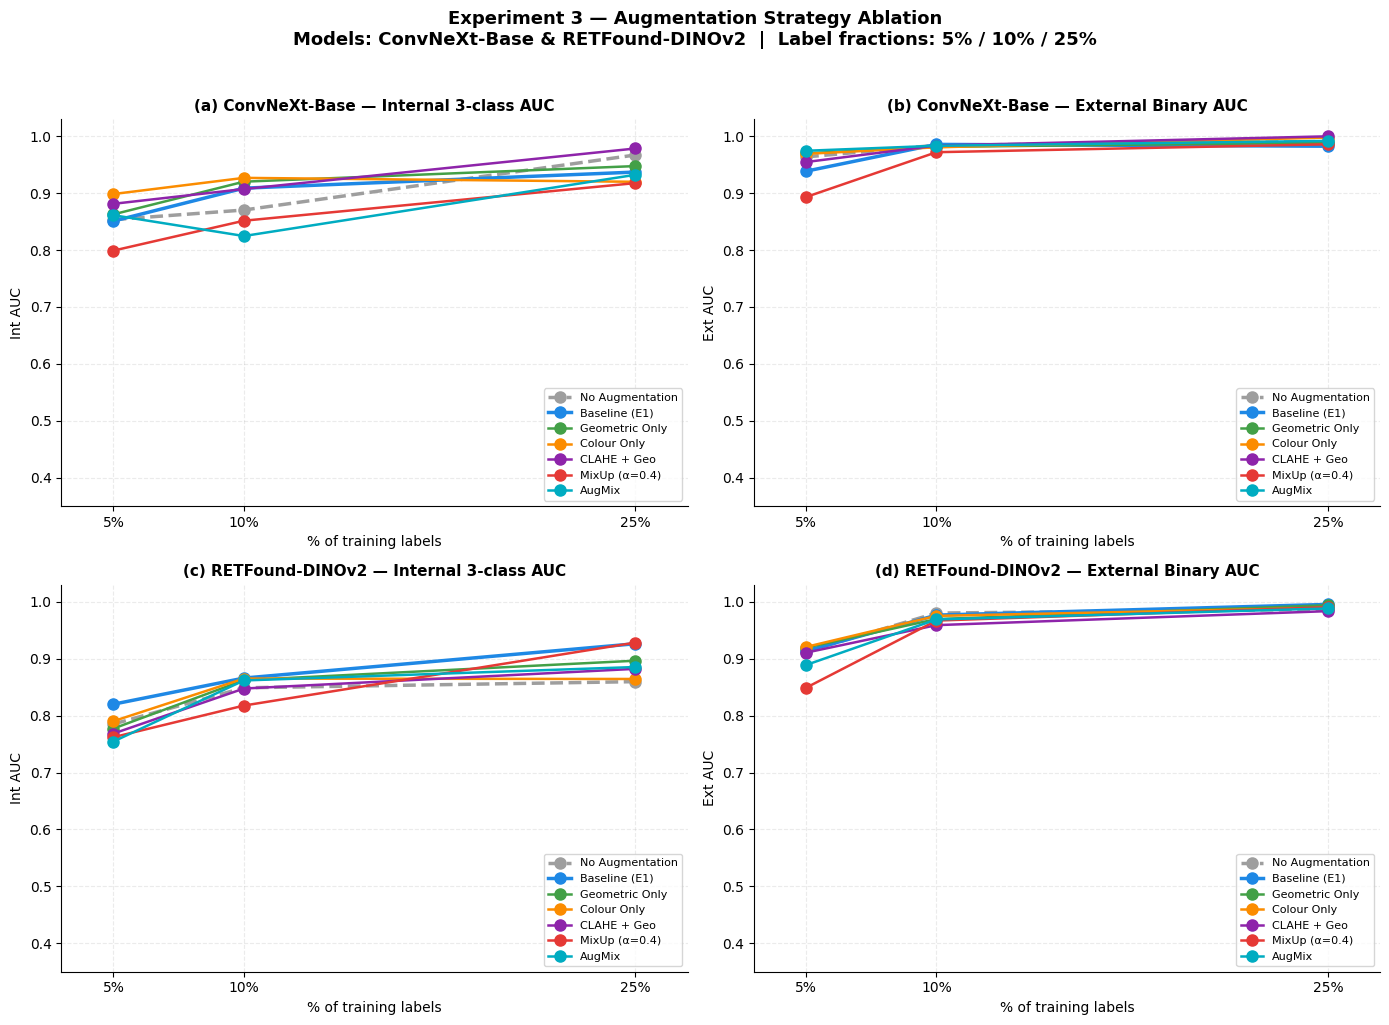

Figure 1 saved.


In [9]:
AUG_COLORS = {
    'A0_NoAug'    : '#9E9E9E',
    'A1_Baseline' : '#1E88E5',
    'A2_GeoOnly'  : '#43A047',
    'A3_ColorOnly': '#FB8C00',
    'A4_CLAHE'    : '#8E24AA',
    'A5_MixUp'    : '#E53935',
    'A6_AugMix'   : '#00ACC1',
}
AUG_LABELS = {
    'A0_NoAug'    : 'No Augmentation',
    'A1_Baseline' : 'Baseline (E1)',
    'A2_GeoOnly'  : 'Geometric Only',
    'A3_ColorOnly': 'Colour Only',
    'A4_CLAHE'    : 'CLAHE + Geo',
    'A5_MixUp'    : 'MixUp (α=0.4)',
    'A6_AugMix'   : 'AugMix',
}
PCTS = [5, 10, 25]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

plot_configs = [
    ('ConvNeXt-Base',   'Int_AUC', '(a) ConvNeXt-Base — Internal 3-class AUC'),
    ('ConvNeXt-Base',   'Ext_AUC', '(b) ConvNeXt-Base — External Binary AUC'),
    ('RETFound-DINOv2', 'Int_AUC', '(c) RETFound-DINOv2 — Internal 3-class AUC'),
    ('RETFound-DINOv2', 'Ext_AUC', '(d) RETFound-DINOv2 — External Binary AUC'),
]

for ax, (model_name, metric, title) in zip(axes, plot_configs):
    sub = results_df[results_df['Model']==model_name]
    for aug_name in AUG_STRATEGIES:
        aug_sub = sub[sub['Aug']==aug_name].sort_values('Fraction')
        if len(aug_sub)==0: continue
        ls = '-' if aug_name=='A1_Baseline' else ('--' if aug_name=='A0_NoAug' else '-')
        lw = 2.5 if aug_name in ['A1_Baseline','A0_NoAug'] else 1.8
        ax.plot(aug_sub['Pct'], aug_sub[metric],
                color=AUG_COLORS[aug_name], linestyle=ls, linewidth=lw,
                marker='o', markersize=8, label=AUG_LABELS[aug_name])

    ax.set_xlabel('% of training labels', fontsize=10)
    ax.set_ylabel(metric.replace('_',' '), fontsize=10)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xticks(PCTS); ax.xaxis.set_major_formatter(mtick.FormatStrFormatter('%d%%'))
    ax.set_xlim(3, 27); ax.set_ylim(0.35, 1.03)
    ax.legend(fontsize=8, loc='lower right')
    ax.grid(True, alpha=0.25, linestyle='--')
    ax.spines[['top','right']].set_visible(False)

plt.suptitle('Experiment 3 — Augmentation Strategy Ablation\n'
             'Models: ConvNeXt-Base & RETFound-DINOv2  |  Label fractions: 5% / 10% / 25%', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('/kaggle/working/e3_fig1_aug_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 1 saved.')

## Cell 10 — Figure 2: Heatmaps (AUC by Aug × Fraction)

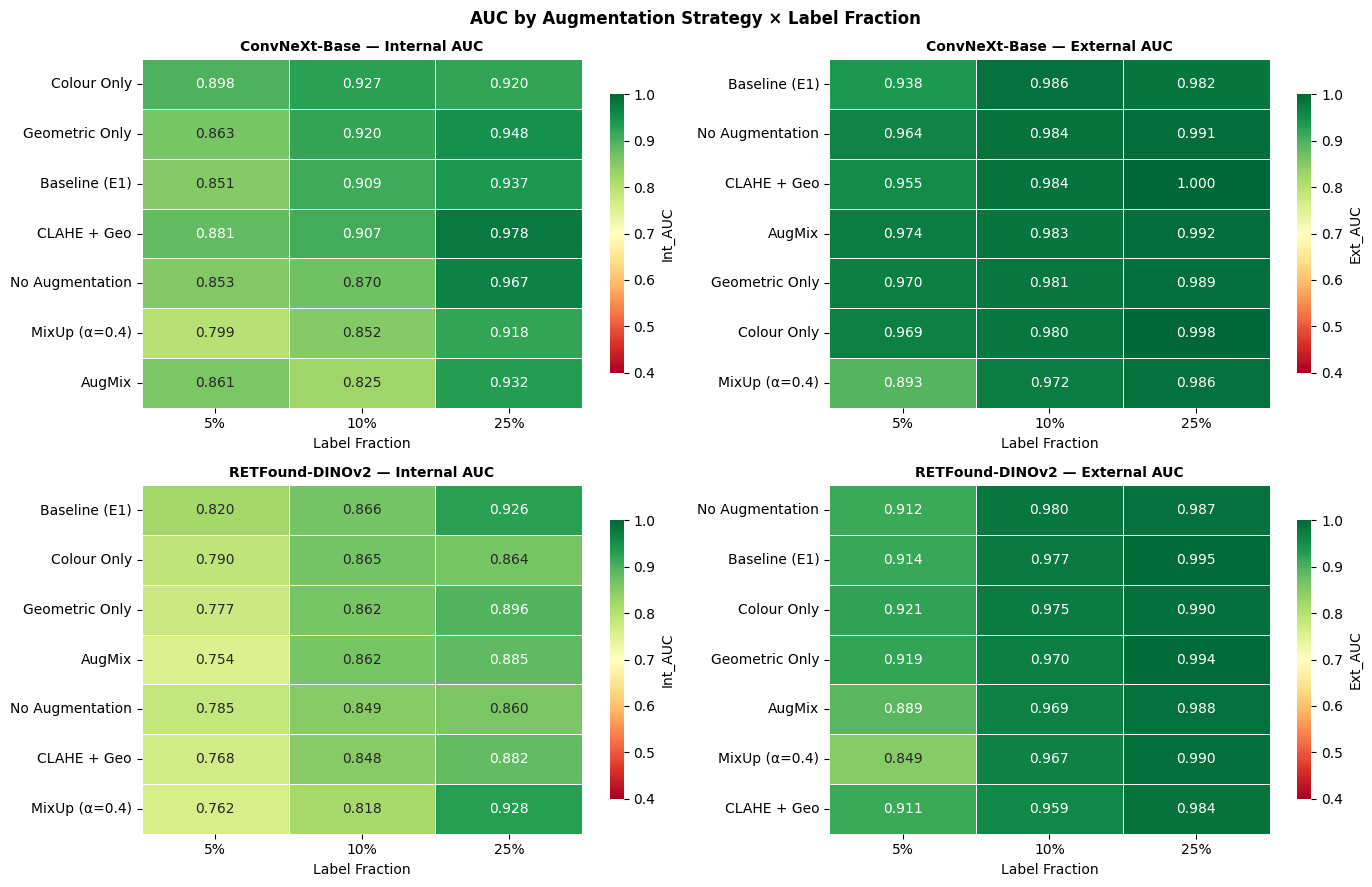

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
configs = [
    ('ConvNeXt-Base',   'Int_AUC', 'ConvNeXt-Base — Internal AUC'),
    ('ConvNeXt-Base',   'Ext_AUC', 'ConvNeXt-Base — External AUC'),
    ('RETFound-DINOv2', 'Int_AUC', 'RETFound-DINOv2 — Internal AUC'),
    ('RETFound-DINOv2', 'Ext_AUC', 'RETFound-DINOv2 — External AUC'),
]

for ax, (model_name, metric, title) in zip(axes.flatten(), configs):
    sub = results_df[results_df['Model']==model_name]
    pivot = sub.pivot_table(index='Aug', columns='Pct', values=metric).round(3)
    pivot.columns = [f'{c}%' for c in pivot.columns]
    pivot.index = [AUG_LABELS[i] for i in pivot.index]
    pivot = pivot.sort_values('10%', ascending=False)
    sns.heatmap(pivot, annot=True, fmt='.3f', cmap='RdYlGn',
                vmin=0.40, vmax=1.00, linewidths=0.5, ax=ax,
                cbar_kws={'label': metric, 'shrink': 0.8})
    ax.set_title(title, fontsize=10, fontweight='bold')
    ax.set_xlabel('Label Fraction'); ax.set_ylabel('')

plt.suptitle('AUC by Augmentation Strategy × Label Fraction', fontweight='bold', fontsize=12)
plt.tight_layout()
plt.savefig('/kaggle/working/e3_fig2_heatmaps.png', dpi=150, bbox_inches='tight')
plt.show()

## Cell 11 — Figure 3: Gain Over No-Aug Baseline

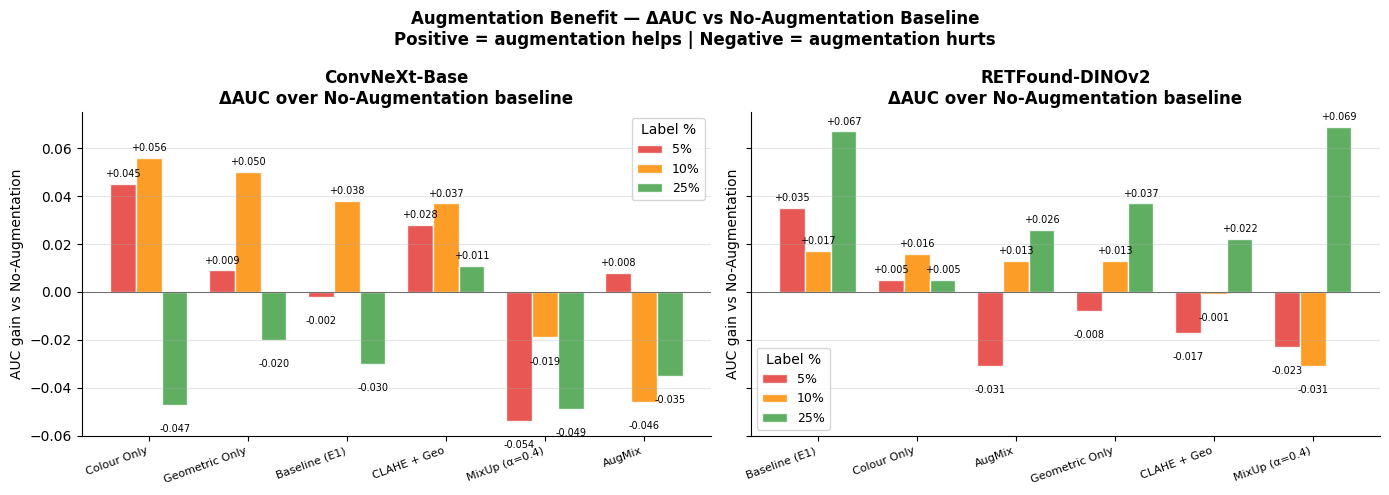

In [11]:
# Compute AUC gain over A0_NoAug for each (model, aug, fraction)
gain_rows = []
for model_name in MODELS_TO_TEST:
    for frac_pct in [5, 10, 25]:
        base = results_df[(results_df['Model']==model_name) &
                          (results_df['Aug']=='A0_NoAug') &
                          (results_df['Pct']==frac_pct)]
        if len(base)==0: continue
        base_auc = base.iloc[0]['Int_AUC']
        for aug_name in AUG_STRATEGIES:
            if aug_name=='A0_NoAug': continue
            row = results_df[(results_df['Model']==model_name) &
                             (results_df['Aug']==aug_name) &
                             (results_df['Pct']==frac_pct)]
            if len(row)==0: continue
            gain = row.iloc[0]['Int_AUC'] - base_auc
            gain_rows.append({'Model':model_name,'Aug':AUG_LABELS[aug_name],
                               'Pct':f'{frac_pct}%','Gain':round(gain,4)})

gain_df = pd.DataFrame(gain_rows)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
for ax, model_name in zip(axes, MODELS_TO_TEST):
    sub = gain_df[gain_df['Model']==model_name]
    pivot = sub.pivot_table(index='Aug', columns='Pct', values='Gain').round(3)
    pivot = pivot.sort_values('10%', ascending=False)
    x = np.arange(len(pivot))
    w = 0.26
    colors_bar = ['#E53935','#FB8C00','#43A047']
    for i, pct in enumerate(['5%','10%','25%']):
        if pct not in pivot.columns: continue
        vals = pivot[pct].values
        bars = ax.bar(x+(i-1)*w, vals, w, label=pct,
                       color=colors_bar[i], alpha=0.85, edgecolor='white')
        for bar, v in zip(bars, vals):
            if not np.isnan(v):
                ax.text(bar.get_x()+bar.get_width()/2,
                        v+(0.002 if v>=0 else -0.008),
                        f'{v:+.3f}', ha='center', va='bottom' if v>=0 else 'top',
                        fontsize=7)
    ax.axhline(0, color='black', linewidth=0.8, alpha=0.5)
    ax.set_xticks(x)
    ax.set_xticklabels(pivot.index, fontsize=8, rotation=20, ha='right')
    ax.set_ylabel('AUC gain vs No-Augmentation')
    ax.set_title(f'{model_name}\nΔAUC over No-Augmentation baseline',fontweight='bold')
    ax.legend(title='Label %', fontsize=9)
    ax.grid(axis='y', alpha=0.3)
    ax.spines[['top','right']].set_visible(False)

plt.suptitle('Augmentation Benefit — ΔAUC vs No-Augmentation Baseline\n'
             'Positive = augmentation helps | Negative = augmentation hurts', fontweight='bold', fontsize=12)
plt.tight_layout()
plt.savefig('/kaggle/working/e3_fig3_gain.png', dpi=150, bbox_inches='tight')
plt.show()

## Cell 12 — Figure 4: Sample Images per Augmentation Strategy

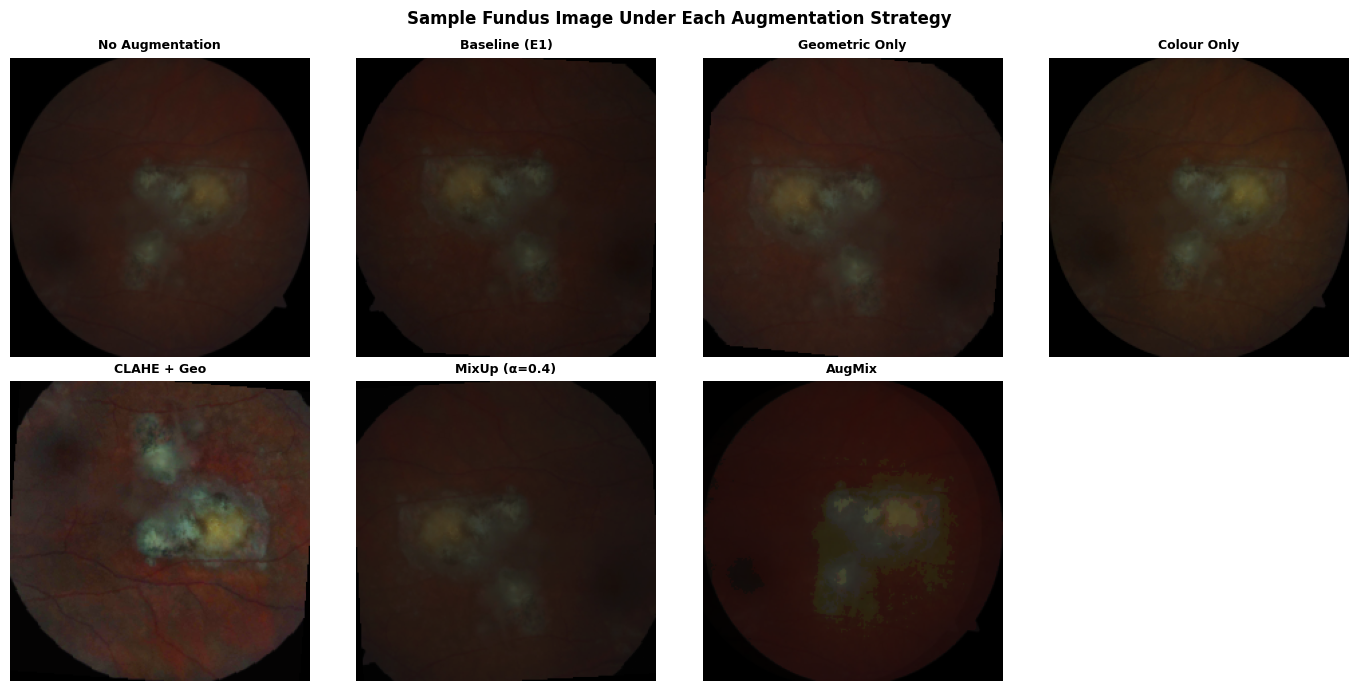

Figure 4 saved.


In [12]:
# Visualise one sample image under each augmentation strategy
sample_path = df.iloc[0]['path']
sample_img  = Image.open(sample_path).convert('RGB')

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
axes = axes.flatten()

for ax, (aug_name, tfm) in zip(axes, AUG_STRATEGIES.items()):
    # Apply transform and denormalise for display
    tensor = tfm(sample_img)
    # Denormalise: img = tensor * std + mean
    mean_t = torch.tensor(MEAN).view(3,1,1)
    std_t  = torch.tensor(STD).view(3,1,1)
    img_display = (tensor * std_t + mean_t).clamp(0,1).permute(1,2,0).numpy()
    ax.imshow(img_display)
    ax.set_title(AUG_LABELS[aug_name], fontsize=9, fontweight='bold')
    ax.axis('off')

# Hide last unused subplot if odd number
for ax in axes[len(AUG_STRATEGIES):]: ax.set_visible(False)

plt.suptitle('Sample Fundus Image Under Each Augmentation Strategy', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('/kaggle/working/e3_fig4_samples.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 4 saved.')

## Cell 13 — Final Summary

In [13]:
print('='*68)
print('  EXPERIMENT 3 — AUGMENTATION ABLATION SUMMARY')
print('  Models: ConvNeXt-Base  &  RETFound-DINOv2')
print('  Metric: Internal 3-class AUC (primary) + External binary AUC')
print('='*68)

for model_name in MODELS_TO_TEST:
    print(f'\n── {model_name} ──')
    sub = results_df[results_df['Model']==model_name]

    # Best aug per fraction
    print('  Best augmentation per label fraction (Internal AUC):')
    for pct in [5, 10, 25]:
        fsub = sub[sub['Pct']==pct]
        if len(fsub):
            best = fsub.loc[fsub['Int_AUC'].idxmax()]
            print(f'    {pct:3d}%  {AUG_LABELS[best.Aug]:25s}  '
                  f'IntAUC={best.Int_AUC:.4f}  ExtAUC={best.Ext_AUC:.4f}')

    # Ranking at 10% labels
    print('  Full ranking at 10% labels (Internal AUC):')
    fsub = sub[sub['Pct']==10].sort_values('Int_AUC', ascending=False)
    for _,r in fsub.iterrows():
        print(f'    {AUG_LABELS[r.Aug]:25s}  IntAUC={r.Int_AUC:.4f}  '
              f'ExtAUC={r.Ext_AUC:.4f}  F1={r.Int_F1:.4f}')

# Average gain of each strategy across both models and all fractions
print('\n── Average AUC gain vs No-Augmentation (both models, all fractions) ──')
aug_gains = []
for aug_name in AUG_STRATEGIES:
    if aug_name == 'A0_NoAug': continue
    gains = []
    for model_name in MODELS_TO_TEST:
        for pct in [5, 10, 25]:
            base = results_df[(results_df['Model']==model_name) &
                               (results_df['Aug']=='A0_NoAug') &
                               (results_df['Pct']==pct)]
            this = results_df[(results_df['Model']==model_name) &
                               (results_df['Aug']==aug_name) &
                               (results_df['Pct']==pct)]
            if len(base) and len(this):
                gains.append(this.iloc[0]['Int_AUC'] - base.iloc[0]['Int_AUC'])
    mean_gain = np.mean(gains) if gains else float('nan')
    aug_gains.append((aug_name, mean_gain))
    print(f'  {AUG_LABELS[aug_name]:25s}: mean ΔAUC = {mean_gain:+.4f}')

best_aug = max(aug_gains, key=lambda x: x[1])
print(f'\n  Best overall: {AUG_LABELS[best_aug[0]]} (mean ΔAUC = {best_aug[1]:+.4f})')

print('\n── Saved figures ──')
for f in sorted(Path('/kaggle/working').glob('e3_fig*.png')):
    print(f'  {f.name}')
print('  experiment3_results.csv')

  EXPERIMENT 3 — AUGMENTATION ABLATION SUMMARY
  Models: ConvNeXt-Base  &  RETFound-DINOv2
  Metric: Internal 3-class AUC (primary) + External binary AUC

── ConvNeXt-Base ──
  Best augmentation per label fraction (Internal AUC):
      5%  Colour Only                IntAUC=0.8984  ExtAUC=0.9690
     10%  Colour Only                IntAUC=0.9268  ExtAUC=0.9805
     25%  CLAHE + Geo                IntAUC=0.9784  ExtAUC=0.9998
  Full ranking at 10% labels (Internal AUC):
    Colour Only                IntAUC=0.9268  ExtAUC=0.9805  F1=0.7811
    Geometric Only             IntAUC=0.9201  ExtAUC=0.9812  F1=0.7068
    Baseline (E1)              IntAUC=0.9087  ExtAUC=0.9856  F1=0.7161
    CLAHE + Geo                IntAUC=0.9072  ExtAUC=0.9836  F1=0.5893
    No Augmentation            IntAUC=0.8703  ExtAUC=0.9841  F1=0.5491
    MixUp (α=0.4)              IntAUC=0.8515  ExtAUC=0.9719  F1=0.3832
    AugMix                     IntAUC=0.8246  ExtAUC=0.9832  F1=0.3829

── RETFound-DINOv2 ──
  Best 